In [36]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.feature_selection import chi2
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

# For better plot style
plt.style.use('ggplot')

In [37]:
#  Load Dataset

wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="target")

df = X.copy()
df["target"] = y

print("Dataset Loaded Successfully ")
print()

Dataset Loaded Successfully 



In [38]:
# EDA

print("Shape of Dataset:", df.shape)

Shape of Dataset: (178, 14)


In [39]:
print("\nFirst 5 Rows:")
print(df.head())


First 5 Rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  targe

In [40]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    flo

In [41]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.572

In [42]:
print("\nClass Distribution:")
print(df["target"].value_counts())


Class Distribution:
target
1    71
0    59
2    48
Name: count, dtype: int64


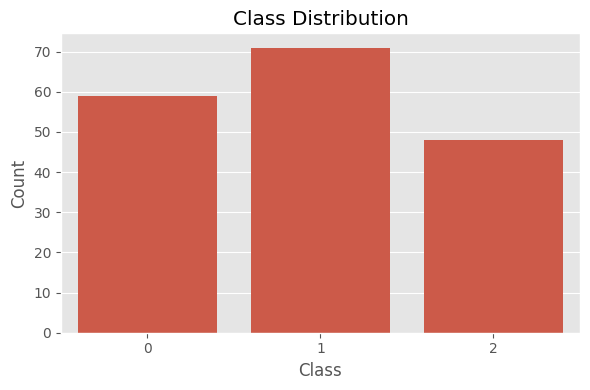

In [43]:
# Plot Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


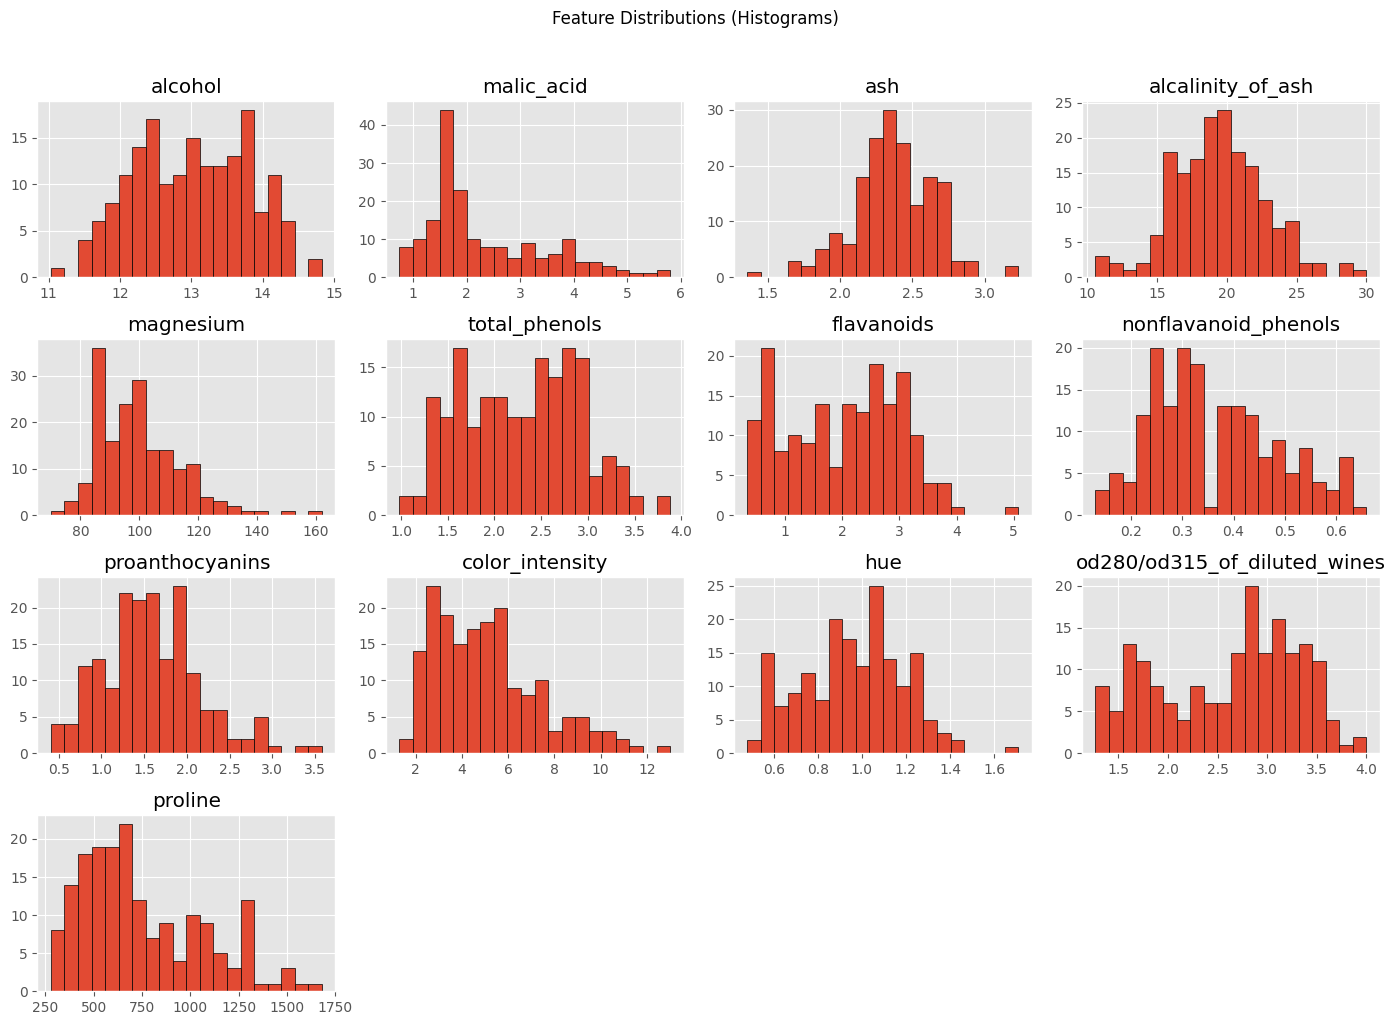

In [44]:
#  Feature Distributions (Histograms)

df.drop("target", axis=1).hist(
    figsize=(14,10),
    bins=20,
    edgecolor="black"
)
plt.suptitle("Feature Distributions (Histograms)", y=1.02)
plt.tight_layout()
plt.show()

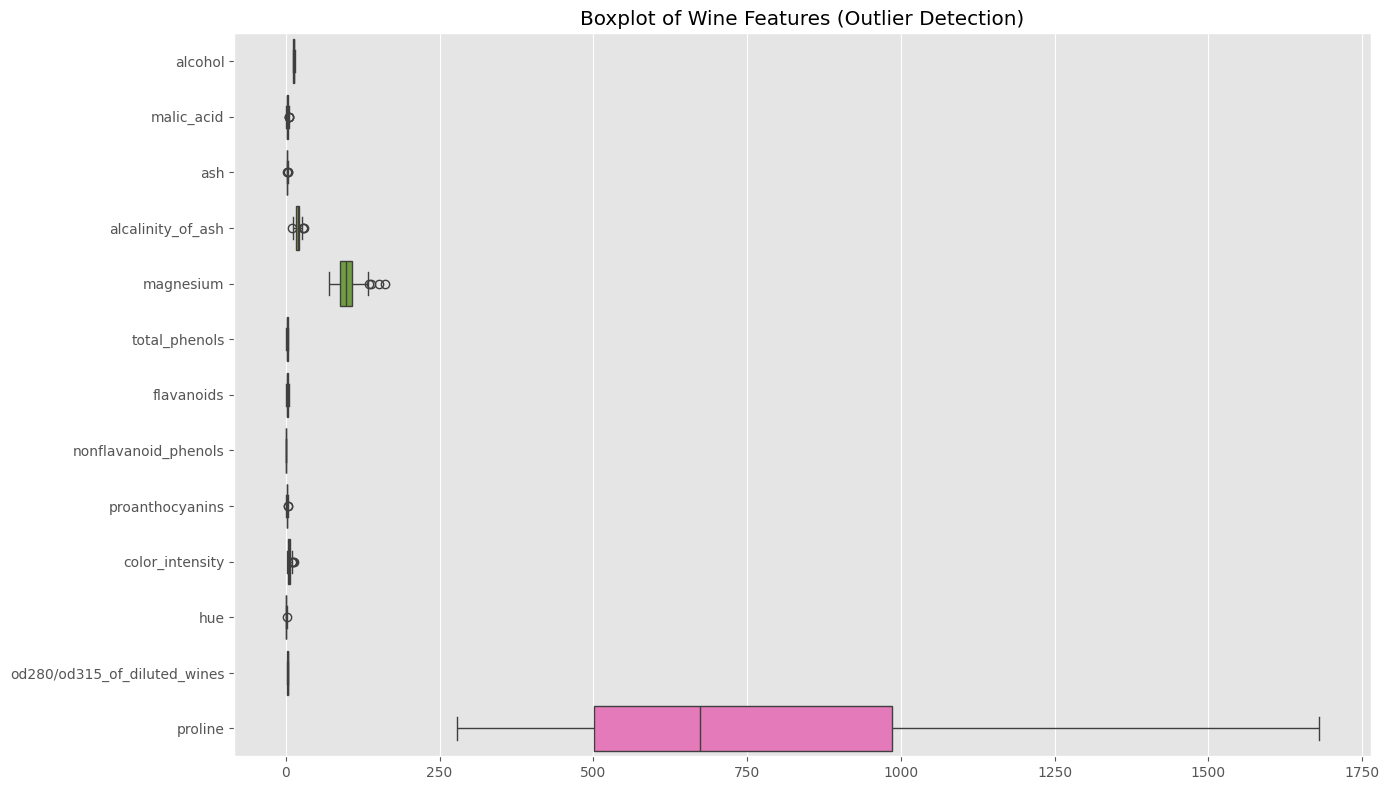

In [45]:
#  Boxplots (Outlier Detection) - All Features

plt.figure(figsize=(14,8))
sns.boxplot(
    data=df.drop("target", axis=1),
    orient="h"
)
plt.title("Boxplot of Wine Features (Outlier Detection)")
plt.tight_layout()
plt.show()

In [46]:
#  Outlier Count Table   IQR Method


outlier_counts = {}

for col in X.columns:
    
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = X[(X[col] < lower_bound) | (X[col] > upper_bound)]
    
    outlier_counts[col] = len(outliers)

outlier_table = pd.DataFrame.from_dict(
    outlier_counts,
    orient="index",
    columns=["Outlier Count"]
)

outlier_table = outlier_table.sort_values(
    by="Outlier Count",
    ascending=False
)

print("\nOutlier Count Table (IQR Method):")
display(outlier_table)


Outlier Count Table (IQR Method):


,Outlier Count
alcalinity_of_ash,4
magnesium,4
color_intensity,4
malic_acid,3
ash,3
proanthocyanins,2
hue,1
alcohol,0
total_phenols,0
flavanoids,0


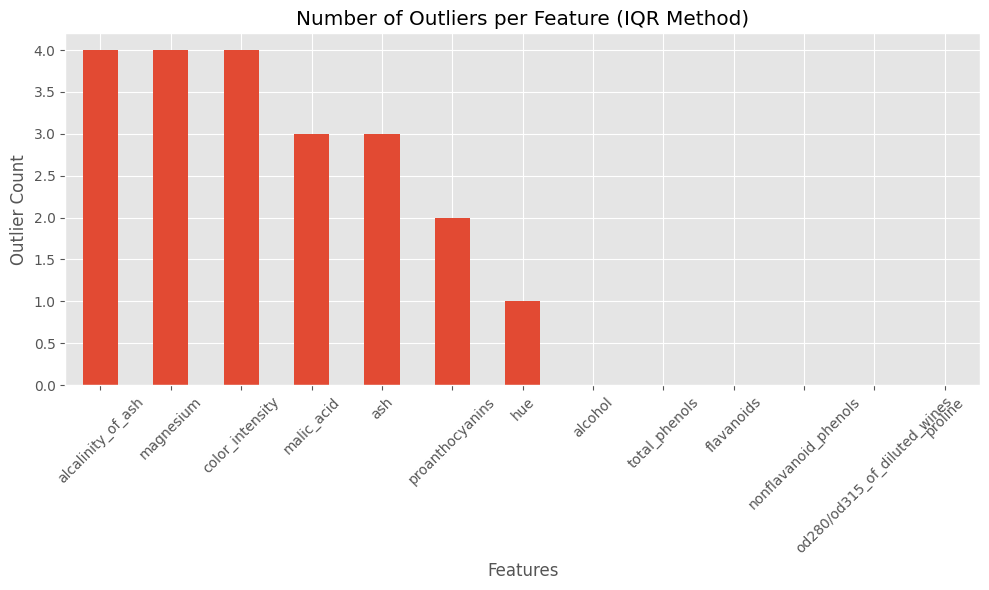

In [47]:
plt.figure(figsize=(10,6))
outlier_table["Outlier Count"].plot(kind="bar")
plt.title("Number of Outliers per Feature (IQR Method)")
plt.ylabel("Outlier Count")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

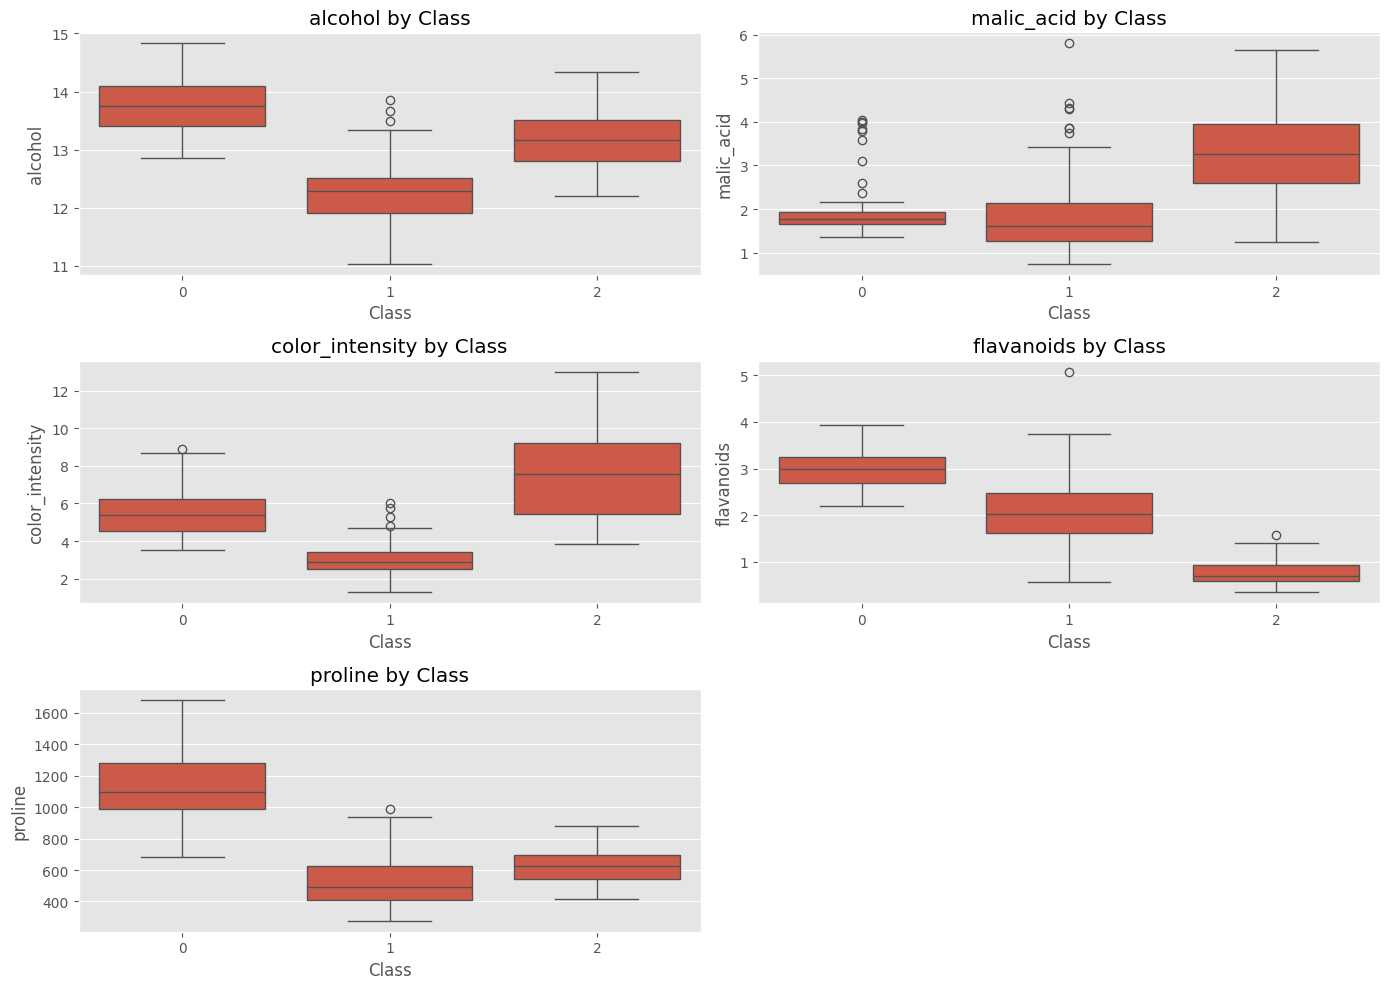

In [48]:
#  Class-wise Boxplots   Selected Features

selected_features = ["alcohol", "malic_acid", "color_intensity", "flavanoids", "proline"]

plt.figure(figsize=(14,10))
for i, feat in enumerate(selected_features, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x="target", y=feat, data=df)
    plt.title(f"{feat} by Class")
    plt.xlabel("Class")
    plt.ylabel(feat)

plt.tight_layout()
plt.show()

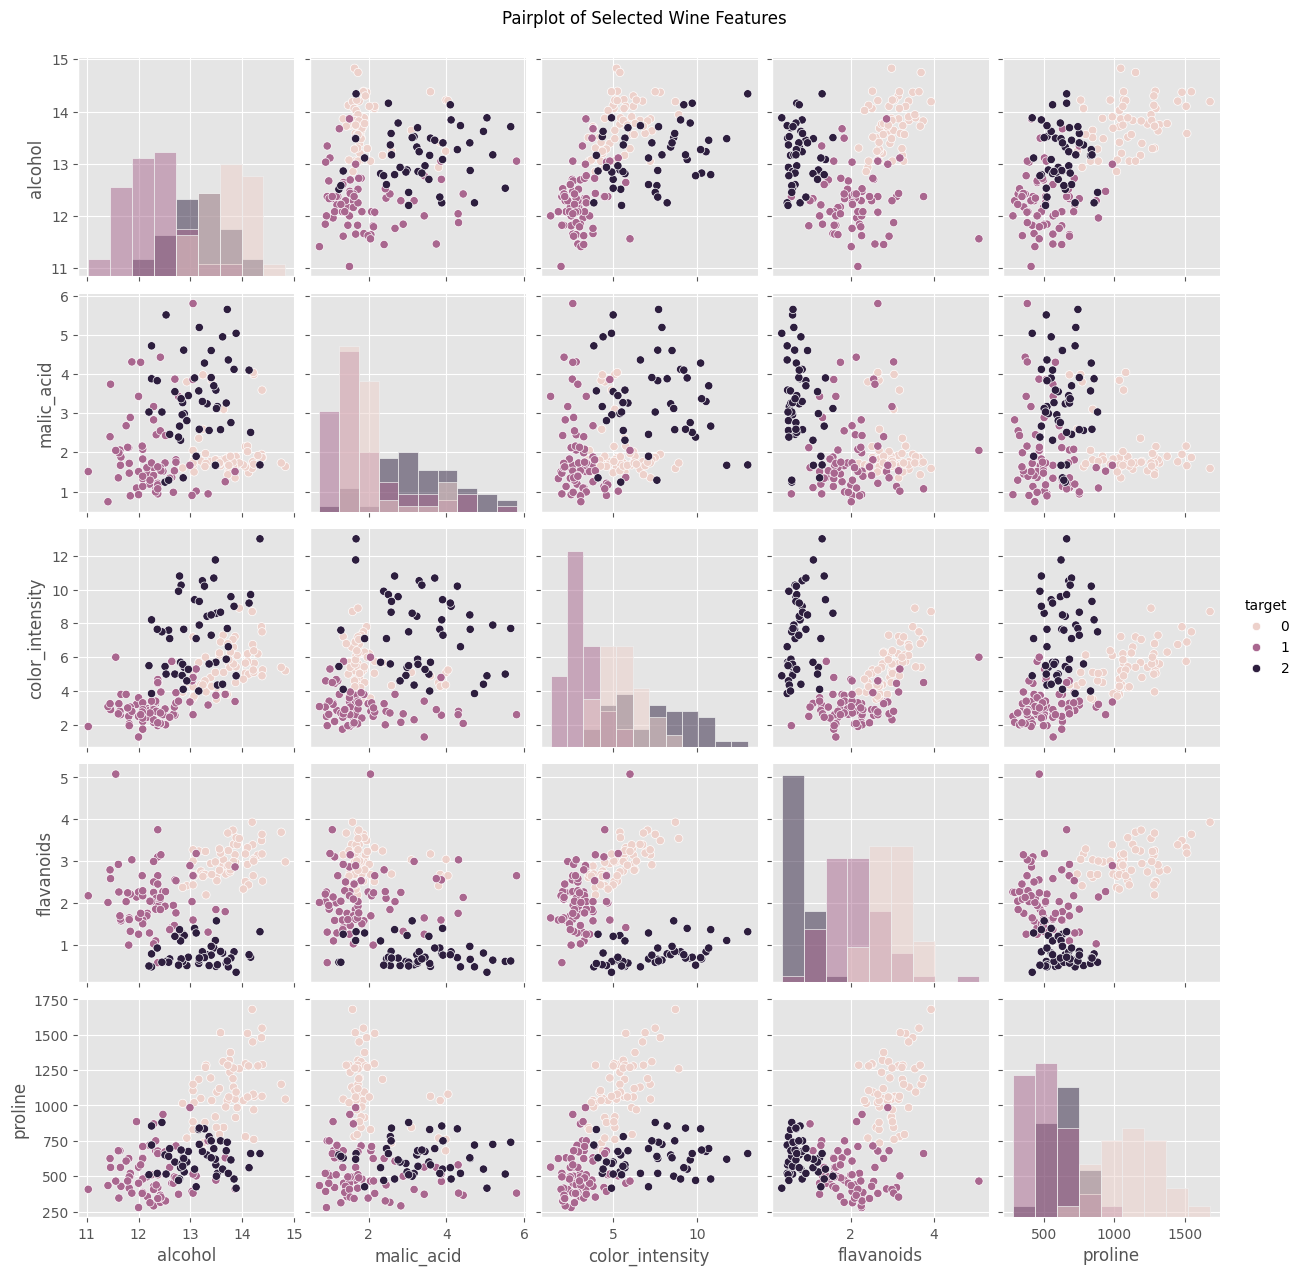

In [49]:
# Pairplot    Selected Features

sns.pairplot(
    df[selected_features + ["target"]],
    hue="target",
    diag_kind="hist"
)
plt.suptitle("Pairplot of Selected Wine Features", y=1.02)
plt.show()

In [50]:
# Data Cleaning Checks

print("\nMissing Values Check:")
print(df.isnull().sum())


Missing Values Check:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64


In [51]:
print("\nDuplicate Rows Check:")
print("Number of duplicates:", df.duplicated().sum())


Duplicate Rows Check:
Number of duplicates: 0


In [52]:
print("\nConclusion:")
print(" Dataset contains NO missing values.")
print(" Dataset contains NO duplicate rows.")


Conclusion:
 Dataset contains NO missing values.
 Dataset contains NO duplicate rows.


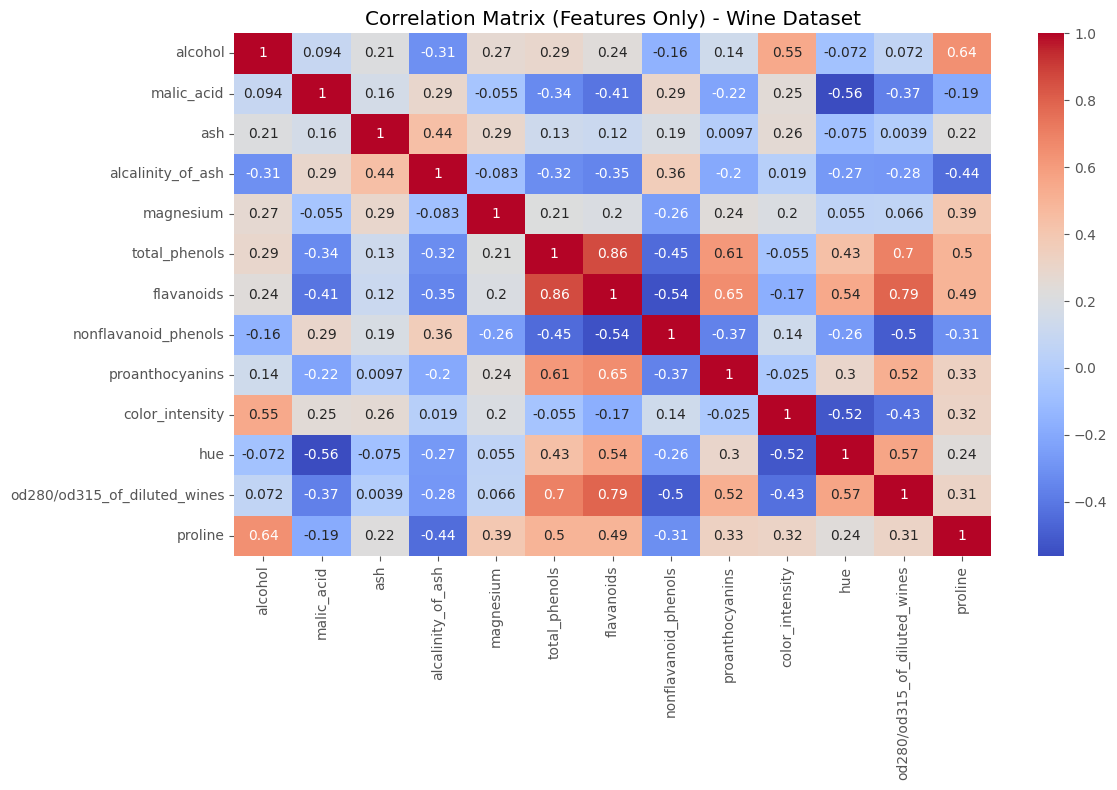

In [53]:
# Correlation Heatmap 

plt.figure(figsize=(12,8))
sns.heatmap(X.corr(), cmap="coolwarm", annot=True)
plt.title("Correlation Matrix (Features Only) - Wine Dataset")
plt.tight_layout()
plt.show()


Pearson Correlation Feature Ranking:

Pearson Ranking:


flavanoids                      0.847498
od280/od315_of_diluted_wines    0.788230
total_phenols                   0.719163
proline                         0.633717
hue                             0.617369
alcalinity_of_ash               0.517859
proanthocyanins                 0.499130
nonflavanoid_phenols            0.489109
malic_acid                      0.437776
alcohol                         0.328222
color_intensity                 0.265668
magnesium                       0.209179
ash                             0.049643
dtype: float64

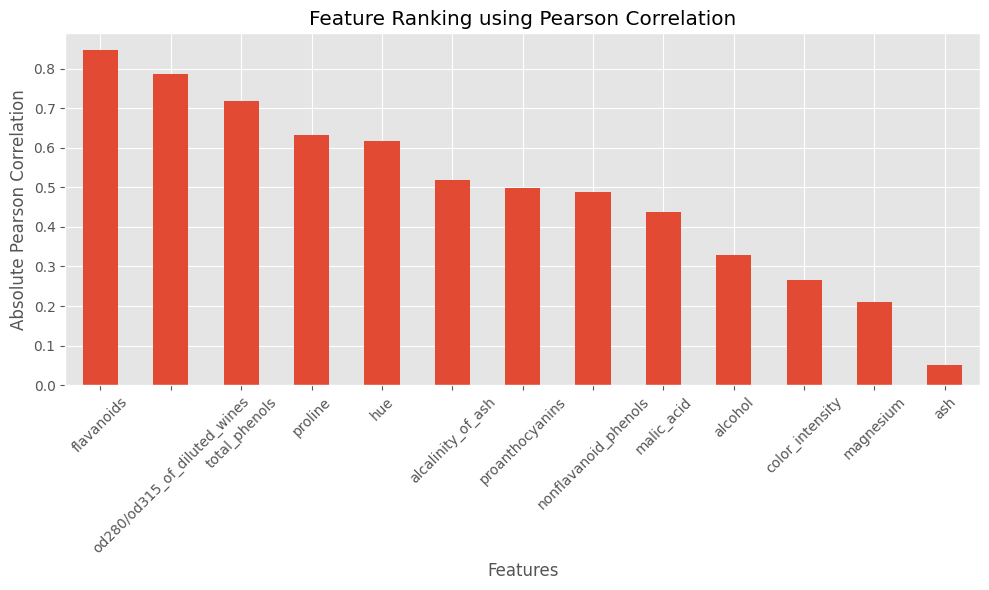

In [54]:
# Pearson Correlation Feature Ranking

print("\nPearson Correlation Feature Ranking:")

pearson_scores = {}

for col in X.columns:
    corr_value = X[col].corr(y)
    pearson_scores[col] = abs(corr_value)

pearson_ranking = pd.Series(pearson_scores).sort_values(ascending=False)

print("\nPearson Ranking:")
display(pearson_ranking)

# Plot Pearson Ranking
plt.figure(figsize=(10,6))
pearson_ranking.plot(kind='bar')
plt.title("Feature Ranking using Pearson Correlation")
plt.xlabel("Features")
plt.ylabel("Absolute Pearson Correlation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [55]:
# Chi-Square Feature Ranking 

class ChiSquaredFeatureSelector:
    """
    Calculates Chi-Square scores manually for each feature
    after discretizing continuous values into bins.
    """

    def __init__(self, target_col=None, bins=5):
        self.target_col = target_col
        self.bins = bins
        self.chi2_scores_ = {}

    def _chi_squared_stat(self, contingency_table):
        observed = contingency_table.values
        row_totals = observed.sum(axis=1)
        col_totals = observed.sum(axis=0)
        total = observed.sum()

        expected = np.outer(row_totals, col_totals) / total
        chi_squared = np.sum((observed - expected) ** 2 / expected)

        return chi_squared

    def fit(self, df):
        if self.target_col is None:
            raise ValueError("target_col must be provided.")

        y = df[self.target_col]

        for col in df.columns:
            if col == self.target_col:
                continue

            # Discretize continuous feature into bins
            binned_feature = pd.cut(df[col], bins=self.bins, labels=False)

            # Create contingency table
            cont_table = pd.crosstab(binned_feature, y)

            # Compute chi-square score manually
            chi_score = self._chi_squared_stat(cont_table)
            self.chi2_scores_[col] = chi_score

        return self


Chi-Square Ranking:


flavanoids                      202.892976
color_intensity                 151.546493
od280/od315_of_diluted_wines    146.909004
proline                         145.127358
hue                             120.304286
alcohol                         116.650265
total_phenols                   109.784968
magnesium                        66.765070
malic_acid                       62.274397
alcalinity_of_ash                61.553153
proanthocyanins                  58.890123
nonflavanoid_phenols             56.097105
ash                              27.411598
dtype: float64

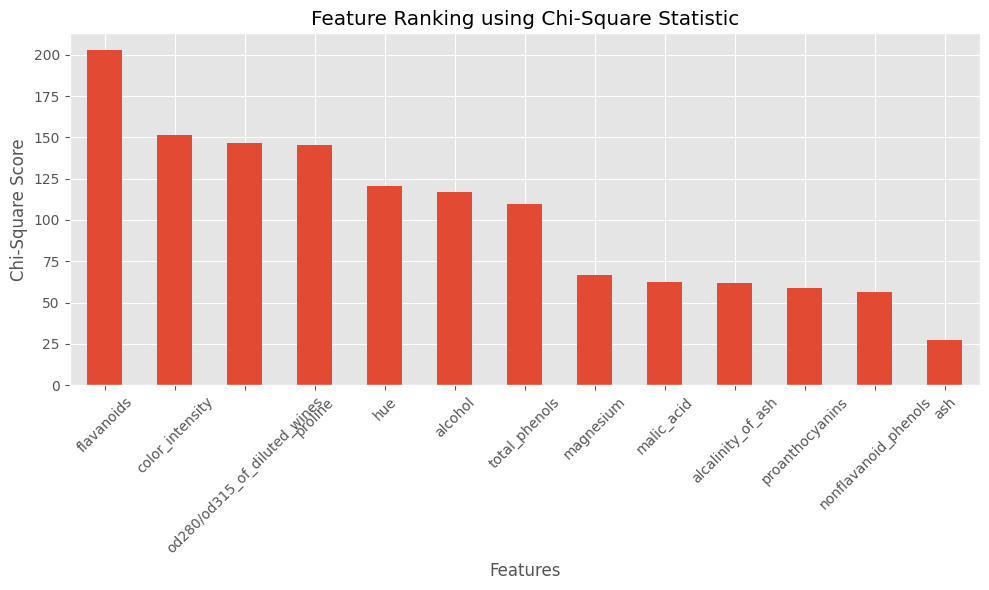

In [56]:
# Apply Chi-Square Selector

chi_df = df.copy()

chi_selector = ChiSquaredFeatureSelector(target_col='target', bins=5)
chi_selector.fit(chi_df)

chi_ranking = pd.Series(chi_selector.chi2_scores_).sort_values(ascending=False)

print("\nChi-Square Ranking:")
display(chi_ranking)

# Plot Chi-Square Ranking
plt.figure(figsize=(10,6))
chi_ranking.plot(kind='bar')
plt.title("Feature Ranking using Chi-Square Statistic")
plt.xlabel("Features")
plt.ylabel("Chi-Square Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [57]:
# Feature Comparison

comparison_df = pd.DataFrame({
    "Pearson Score": pearson_ranking,
    "Chi-Square Score": chi_ranking
})

comparison_df["Pearson Rank"] = comparison_df["Pearson Score"].rank(ascending=False, method="dense").astype(int)
comparison_df["Chi-Square Rank"] = comparison_df["Chi-Square Score"].rank(ascending=False, method="dense").astype(int)

comparison_df = comparison_df.sort_values(by="Pearson Rank")

print("\nFeature Comparison Table:")
display(comparison_df)


Feature Comparison Table:


,Pearson Score,Chi-Square Score,Pearson Rank,Chi-Square Rank
flavanoids,0.847498,202.892976,1,1
od280/od315_of_diluted_wines,0.788230,146.909004,2,3
total_phenols,0.719163,109.784968,3,7
proline,0.633717,145.127358,4,4
hue,0.617369,120.304286,5,5
alcalinity_of_ash,0.517859,61.553153,6,10
proanthocyanins,0.499130,58.890123,7,11
nonflavanoid_phenols,0.489109,56.097105,8,12
malic_acid,0.437776,62.274397,9,9
alcohol,0.328222,116.650265,10,6


In [58]:
#  Top-K Features

k = 5

top_k_pearson = pearson_ranking.head(k)
top_k_chi = chi_ranking.head(k)

print(f"\nTop {k} Features based on Pearson Correlation:")
print(top_k_pearson)

print(f"\nTop {k} Features based on Chi-Square:")
display(top_k_chi)


Top 5 Features based on Pearson Correlation:
flavanoids                      0.847498
od280/od315_of_diluted_wines    0.788230
total_phenols                   0.719163
proline                         0.633717
hue                             0.617369
dtype: float64

Top 5 Features based on Chi-Square:


flavanoids                      202.892976
color_intensity                 151.546493
od280/od315_of_diluted_wines    146.909004
proline                         145.127358
hue                             120.304286
dtype: float64

In [59]:
# Save Rankings 
comparison_df.to_csv("feature_ranking.csv")


Spearman Rank Correlation Feature Ranking:

Spearman Ranking:
flavanoids                      0.854908
od280/od315_of_diluted_wines    0.743787
total_phenols                   0.726544
hue                             0.616570
proline                         0.576383
proanthocyanins                 0.570648
alcalinity_of_ash               0.569792
nonflavanoid_phenols            0.474205
alcohol                         0.354167
malic_acid                      0.346913
magnesium                       0.250498
color_intensity                 0.131170
ash                             0.053988
dtype: float64


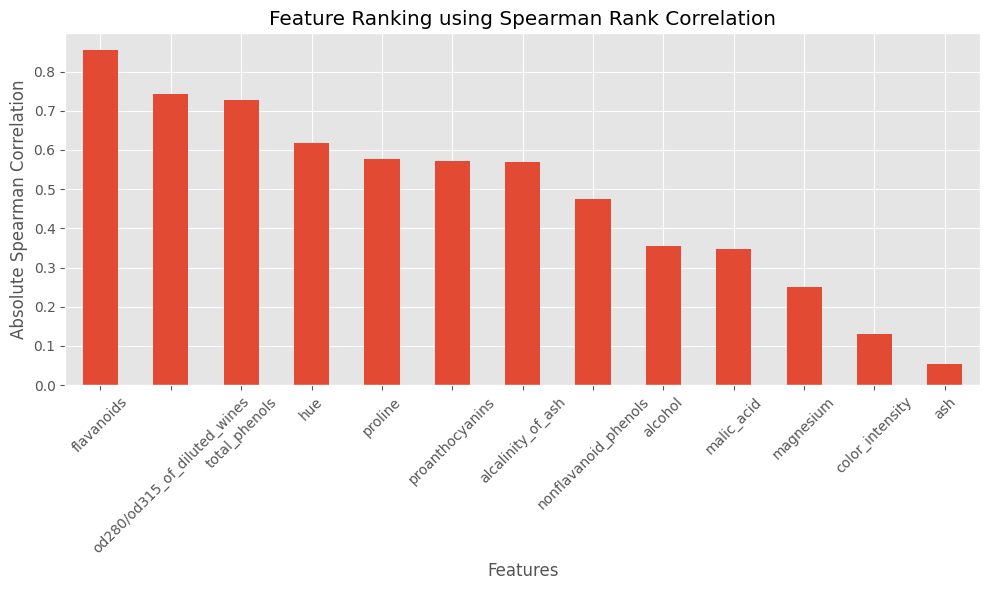

In [60]:
# Spearman Rank Correlation


print("\nSpearman Rank Correlation Feature Ranking:")

spearman_scores = {}

for col in X.columns:
    corr_value = X[col].corr(y, method="spearman")
    spearman_scores[col] = abs(corr_value)

spearman_ranking = pd.Series(spearman_scores).sort_values(ascending=False)

print("\nSpearman Ranking:")
print(spearman_ranking)

# Plot Spearman Ranking
plt.figure(figsize=(10,6))
spearman_ranking.plot(kind='bar')
plt.title("Feature Ranking using Spearman Rank Correlation")
plt.xlabel("Features")
plt.ylabel("Absolute Spearman Correlation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [61]:

# Gini Index Feature Ranking


class GiniFeatureSelector:


    def __init__(self, k, target_col, bins=5):
        self.k = k
        self.target_col = target_col
        self.bins = bins
        self.gini_scores_ = {}
        self.selected_features_ = []

    def _gini(self, y):
        counts = np.bincount(y)
        probabilities = counts / len(y)
        return 1 - np.sum(probabilities ** 2)

    def _weighted_gini(self, X_col, y):
        unique_values, counts = np.unique(X_col, return_counts=True)
        weighted_gini = 0

        for value, count in zip(unique_values, counts):
            y_subset = y[X_col == value]
            weight = count / len(y)
            weighted_gini += weight * self._gini(y_subset)

        return weighted_gini

    def _calculate_gini_scores(self, df):
        y = df[self.target_col].values
        gini_scores = {}

        for col in df.columns:
            if col == self.target_col:
                continue

            # Convert continuous feature into bins
            binned_feature = pd.cut(df[col], bins=self.bins, labels=False)

            X_col = binned_feature.values
            gini_scores[col] = self._weighted_gini(X_col, y)

        return gini_scores

    def fit(self, df):
        if self.target_col is None:
            raise ValueError("target_col must be provided.")

        self.gini_scores_ = self._calculate_gini_scores(df)

        # Lower Gini = better feature
        sorted_features = sorted(
            self.gini_scores_,
            key=self.gini_scores_.get
        )

        self.selected_features_ = sorted_features[:self.k]

        return self

    def transform(self, df):
        return df[self.selected_features_ + [self.target_col]]

    def fit_transform(self, df):
        return self.fit(df).transform(df)





Gini Ranking:
flavanoids                      0.297733
color_intensity                 0.365062
proline                         0.382828
od280/od315_of_diluted_wines    0.411704
alcohol                         0.423264
hue                             0.455662
total_phenols                   0.468600
magnesium                       0.523013
alcalinity_of_ash               0.550034
malic_acid                      0.552397
proanthocyanins                 0.559815
nonflavanoid_phenols            0.562133
ash                             0.603486
dtype: float64

Selected Features using Gini:
['flavanoids', 'color_intensity', 'proline', 'od280/od315_of_diluted_wines', 'alcohol']


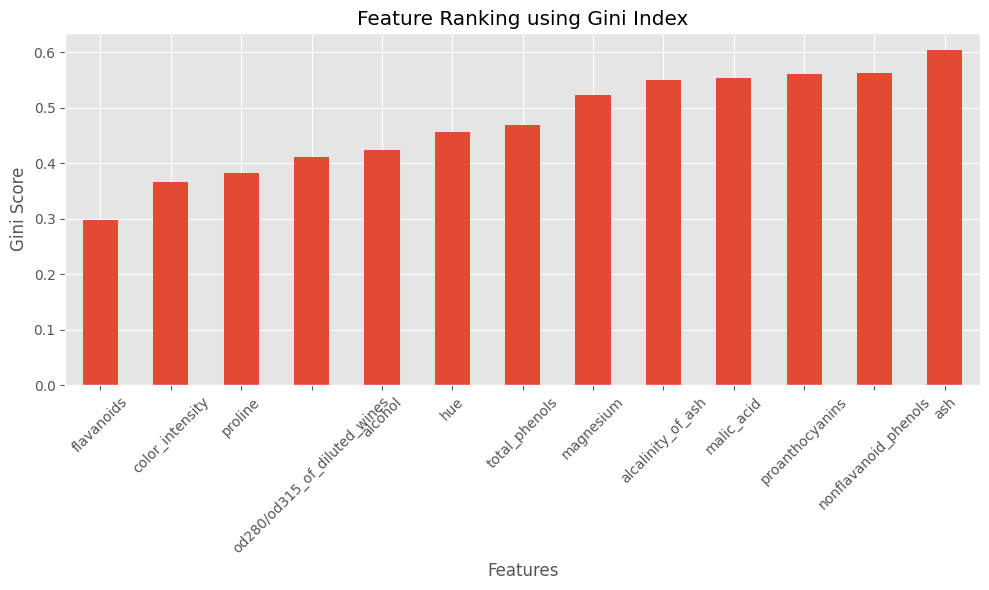

In [62]:
# Apply Gini Selector
gini_selector = GiniFeatureSelector(k=5, target_col="target", bins=5)
gini_selector.fit(df)

gini_ranking = pd.Series(gini_selector.gini_scores_).sort_values(ascending=True)

print("\nGini Ranking:")
print(gini_ranking)

print("\nSelected Features using Gini:")
print(gini_selector.selected_features_)

# Plot Gini Ranking
plt.figure(figsize=(10,6))
gini_ranking.plot(kind='bar')
plt.title("Feature Ranking using Gini Index")
plt.xlabel("Features")
plt.ylabel("Gini Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [63]:
# Feature Comparison


comparison_phase2 = pd.DataFrame({
    "Spearman Score": spearman_ranking,
    "Gini Score": gini_ranking
})

comparison_phase2["Spearman Rank"] = comparison_phase2["Spearman Score"].rank(
    ascending=False, method="dense"
).astype(int)

comparison_phase2["Gini Rank"] = comparison_phase2["Gini Score"].rank(
    ascending=True, method="dense"
).astype(int)

comparison_phase2 = comparison_phase2.sort_values(by="Spearman Rank")

print("\nPhase 2 Feature Comparison Table:")
display(comparison_phase2)


Phase 2 Feature Comparison Table:


,Spearman Score,Gini Score,Spearman Rank,Gini Rank
flavanoids,0.854908,0.297733,1,1
od280/od315_of_diluted_wines,0.743787,0.411704,2,4
total_phenols,0.726544,0.468600,3,7
hue,0.616570,0.455662,4,6
proline,0.576383,0.382828,5,3
proanthocyanins,0.570648,0.559815,6,11
alcalinity_of_ash,0.569792,0.550034,7,9
nonflavanoid_phenols,0.474205,0.562133,8,12
alcohol,0.354167,0.423264,9,5
malic_acid,0.346913,0.552397,10,10


In [64]:
# Save Results

comparison_phase2.to_csv("phase2_feature_ranking.csv", index=True)


## Pearson Correlation


In [65]:
# 1. Pearson Correlation Feature Ranking
print("\nPearson Correlation Feature Ranking ")
pearson_scores = {}
for col in X.columns:
    corr_value = X[col].corr(y)
    pearson_scores[col] = abs(corr_value)

pearson_ranking = pd.Series(pearson_scores).sort_values(ascending=False)
display(pearson_ranking)



Pearson Correlation Feature Ranking 


flavanoids                      0.847498
od280/od315_of_diluted_wines    0.788230
total_phenols                   0.719163
proline                         0.633717
hue                             0.617369
alcalinity_of_ash               0.517859
proanthocyanins                 0.499130
nonflavanoid_phenols            0.489109
malic_acid                      0.437776
alcohol                         0.328222
color_intensity                 0.265668
magnesium                       0.209179
ash                             0.049643
dtype: float64

## Information Gain (Entropy-based)

In [66]:
# 5. Information Gain Feature Ranking
class InformationGainFeatureSelector:
    def __init__(self, target_col, bins=5):
        self.target_col = target_col
        self.bins = bins
        self.info_gains_ = {}

    def _entropy(self, y_sub):
        counts = np.bincount(y_sub)
        probabilities = counts / len(y_sub)
        return -np.sum([p * np.log2(p) for p in probabilities if p > 0])

    def _conditional_entropy(self, X_col, y_sub):
        unique_values, counts = np.unique(X_col, return_counts=True)
        conditional_ent = 0
        for value, count in zip(unique_values, counts):
            y_subset = y_sub[X_col == value]
            weight = count / len(y_sub)
            conditional_ent += weight * self._entropy(y_subset)
        return conditional_ent

    def fit(self, df):
        y_vals = df[self.target_col].values
        Hy = self._entropy(y_vals)
        for col in df.columns:
            if col == self.target_col: continue
            binned_feature = pd.cut(df[col], bins=self.bins, labels=False).values
            self.info_gains_[col] = Hy - self._conditional_entropy(binned_feature, y_vals)
        return self

print("\n--- Information Gain Feature Ranking ---")
ig_selector = InformationGainFeatureSelector(target_col="target", bins=5)
ig_selector.fit(df)
ig_ranking = pd.Series(ig_selector.info_gains_).sort_values(ascending=False)
display(ig_ranking)


--- Information Gain Feature Ranking ---


flavanoids                      0.881030
od280/od315_of_diluted_wines    0.695036
color_intensity                 0.681267
proline                         0.663099
alcohol                         0.560064
hue                             0.548385
total_phenols                   0.530020
magnesium                       0.328641
proanthocyanins                 0.283337
alcalinity_of_ash               0.280095
malic_acid                      0.255943
nonflavanoid_phenols            0.248895
ash                             0.119318
dtype: float64

## Multi-Class LDA Implementation
We create the LDA model from scratch, extracting transformation matrix and making predictions using class prototypes.

In [67]:
class LDA:
    def __init__(self, n_components=None):
        self.n_components = n_components
        self.eigenvectors = None
        self.class_means = {}
        self.classes = None

    def fit(self, x, y):
        x = np.array(x)
        y = np.array(y)
        self.classes = np.unique(y)
        overall_mean = np.mean(x, axis=0)
        n_features = x.shape[1]

        Sb = np.zeros((n_features, n_features))
        Sw = np.zeros((n_features, n_features))

        for c in self.classes:
            x_c = x[y==c]
            x_c_mean = np.mean(x_c, axis=0)
            n_class_samples = len(x_c)
            self.class_means[c] = x_c_mean

            mean_diff = (x_c_mean - overall_mean).reshape(-1,1)
            Sb += n_class_samples * (mean_diff @ mean_diff.T)
            Sw += (x_c - x_c_mean).T @ (x_c - x_c_mean)

        A = np.linalg.pinv(Sw) @ Sb
        eigenvalues, eigenvectors = np.linalg.eig(A)

        sorted_idx = np.argsort(eigenvalues)[::-1]
        sorted_eigenvectors = np.real(eigenvectors[:, sorted_idx])

        if self.n_components:
            sorted_eigenvectors = sorted_eigenvectors[:, :self.n_components]

        self.eigenvectors = sorted_eigenvectors

    def transform(self, x):
        return np.real(np.array(x) @ self.eigenvectors)
    
    def predict(self, x):
        # Predict using Euclidean distance to the projected class means
        x_proj = self.transform(x)
        predictions = []
        for sample in x_proj:
            best_class = None
            min_dist = float('inf')
            for c in self.classes:
                mean_proj = self.transform(self.class_means[c].reshape(1, -1))[0]
                dist = np.linalg.norm(sample - mean_proj)
                if dist < min_dist:
                    min_dist = dist
                    best_class = c
            predictions.append(best_class)
        return np.array(predictions)


## Compare Stability and Performance
We use 5-Fold Stratified Cross-Validation onto the Multi-class LDA to evaluate and compare stability (Standard Deviation) and performance (Mean Accuracy) between criteria.


In [68]:
# Create top_k_features dictionary combining all metrics
# Create top_k_features dictionary combining all metrics

# compute the top‑k for Spearman and Gini as well
top_k_spearman = spearman_ranking.head(k)
top_k_gini      = gini_ranking.head(k)

top_k_features = {
    'Pearson'         : list(top_k_pearson.index),
    'Chi-Square'      : list(top_k_chi.index),
    'Spearman'        : list(top_k_spearman.index),
    'Gini'            : list(top_k_gini.index),
    'Information Gain': list(ig_ranking.head(k).index)
}

print("Top-K Features Dictionary:")
for metric, features in top_k_features.items():
    print(f"{metric}: {features}")

print("Top-K Features Dictionary:")
for metric, features in top_k_features.items():
    print(f"{metric}: {features}")



Top-K Features Dictionary:
Pearson: ['flavanoids', 'od280/od315_of_diluted_wines', 'total_phenols', 'proline', 'hue']
Chi-Square: ['flavanoids', 'color_intensity', 'od280/od315_of_diluted_wines', 'proline', 'hue']
Spearman: ['flavanoids', 'od280/od315_of_diluted_wines', 'total_phenols', 'hue', 'proline']
Gini: ['flavanoids', 'color_intensity', 'proline', 'od280/od315_of_diluted_wines', 'alcohol']
Information Gain: ['flavanoids', 'od280/od315_of_diluted_wines', 'color_intensity', 'proline', 'alcohol']
Top-K Features Dictionary:
Pearson: ['flavanoids', 'od280/od315_of_diluted_wines', 'total_phenols', 'proline', 'hue']
Chi-Square: ['flavanoids', 'color_intensity', 'od280/od315_of_diluted_wines', 'proline', 'hue']
Spearman: ['flavanoids', 'od280/od315_of_diluted_wines', 'total_phenols', 'hue', 'proline']
Gini: ['flavanoids', 'color_intensity', 'proline', 'od280/od315_of_diluted_wines', 'alcohol']
Information Gain: ['flavanoids', 'od280/od315_of_diluted_wines', 'color_intensity', 'proline',

,Metric,Mean CV Accuracy,CV Std / Stability
3,Gini,0.966032,0.028062
4,Information Gain,0.966032,0.028062
1,Chi-Square,0.960635,0.029081
0,Pearson,0.926825,0.023114
2,Spearman,0.926825,0.023114


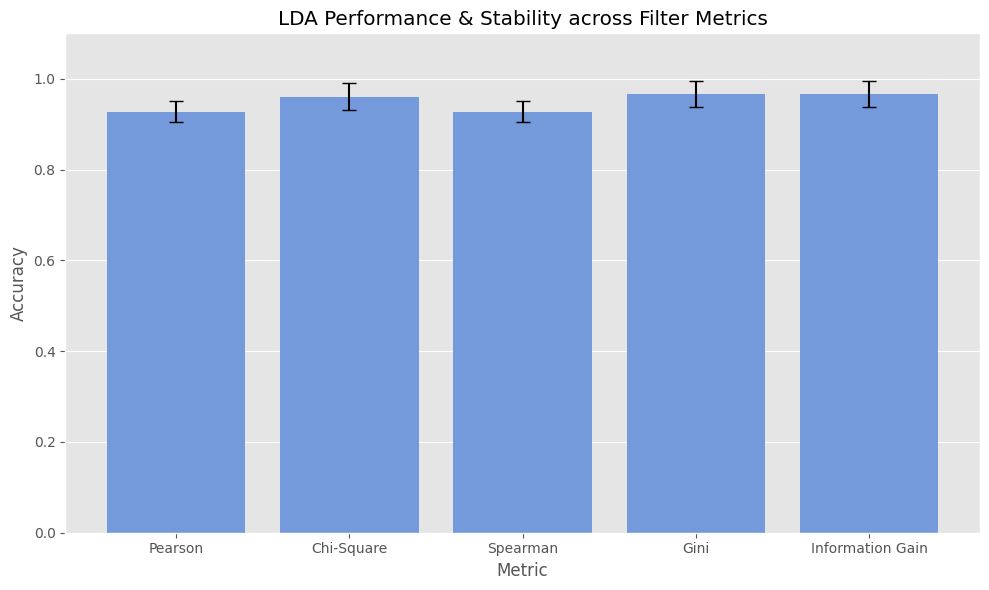

In [69]:
# Evaluate stability and performance using cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for metric, features in top_k_features.items():
    X_subset = df[features].values
    y_vals = df['target'].values
    
    fold_accuracies = []
    
    for train_index, test_index in skf.split(X_subset, y_vals):
        X_train, X_test = X_subset[train_index], X_subset[test_index]
        y_train, y_test = y_vals[train_index], y_vals[test_index]
        
        # Train LDA using at most C-1 components (Wine dataset has 3 classes, so n_components=2)
        lda = LDA(n_components=2)
        lda.fit(X_train, y_train)
        y_pred = lda.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        fold_accuracies.append(acc)
        
    results.append({
        'Metric': metric,
        'Mean CV Accuracy': np.mean(fold_accuracies),
        'CV Std / Stability': np.std(fold_accuracies)
    })

results_df = pd.DataFrame(results)
display(results_df.sort_values(by='Mean CV Accuracy', ascending=False))

# Plot Stability and Performance
plt.figure(figsize=(10,6))
sns.barplot(x='Metric', y='Mean CV Accuracy', data=results_df, color='cornflowerblue')
plt.errorbar(x=range(len(results_df)), y=results_df['Mean CV Accuracy'], 
             yerr=results_df['CV Std / Stability'], fmt='none', c='black', capsize=5)
plt.title("LDA Performance & Stability across Filter Metrics")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()


In [ ]:
### NEW SECTION: Manual Correlation and Safe Chi-Square Utilities

from sklearn.metrics import confusion_matrix, precision_recall_fscore_support


def _rank_average_ties(values):
    values = np.asarray(values, dtype=float)
    order = np.argsort(values, kind="mergesort")
    sorted_vals = values[order]
    ranks = np.zeros(len(values), dtype=float)

    i = 0
    while i < len(values):
        j = i
        while j + 1 < len(values) and sorted_vals[j + 1] == sorted_vals[i]:
            j += 1
        avg_rank = (i + j + 2) / 2.0
        ranks[order[i:j+1]] = avg_rank
        i = j + 1
    return ranks


def _pearson_from_vectors(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    x_centered = x - x_mean
    y_centered = y - y_mean

    covariance = np.sum(x_centered * y_centered)
    x_std_term = np.sqrt(np.sum(x_centered ** 2))
    y_std_term = np.sqrt(np.sum(y_centered ** 2))

    denominator = x_std_term * y_std_term
    if denominator == 0:
        return 0.0
    return covariance / denominator


def compute_pearson_manual(X, y):
    """Compute absolute Pearson correlation per feature using covariance/std formula."""
    X_df = pd.DataFrame(X)
    y_vec = np.asarray(y, dtype=float)
    scores = {}

    for col in X_df.columns:
        corr = _pearson_from_vectors(X_df[col].values, y_vec)
        scores[col] = abs(corr)

    return pd.Series(scores).sort_values(ascending=False)


def compute_spearman_manual(X, y):
    """Compute absolute Spearman correlation by ranking then applying Pearson."""
    X_df = pd.DataFrame(X)
    y_rank = _rank_average_ties(np.asarray(y, dtype=float))
    scores = {}

    for col in X_df.columns:
        x_rank = _rank_average_ties(X_df[col].values)
        corr = _pearson_from_vectors(x_rank, y_rank)
        scores[col] = abs(corr)

    return pd.Series(scores).sort_values(ascending=False)


def safe_chi_square_stat(contingency_table):
    """Safe Chi-square statistic that avoids division by zero for expected frequencies."""
    observed = contingency_table.values.astype(float)
    row_totals = observed.sum(axis=1)
    col_totals = observed.sum(axis=0)
    total = observed.sum()

    if total == 0:
        return 0.0

    expected = np.outer(row_totals, col_totals) / total
    valid_mask = expected > 0

    chi_terms = np.zeros_like(expected)
    chi_terms[valid_mask] = ((observed[valid_mask] - expected[valid_mask]) ** 2) / expected[valid_mask]
    return float(np.sum(chi_terms))


class SafeChiSquaredFeatureSelector:
    def __init__(self, target_col=None, bins=5):
        self.target_col = target_col
        self.bins = bins
        self.chi2_scores_ = {}

    def fit(self, df):
        self.chi2_scores_ = {}
        y_vals = df[self.target_col]

        for col in df.columns:
            if col == self.target_col:
                continue
            binned = pd.cut(df[col], bins=self.bins, labels=False, include_lowest=True)
            contingency = pd.crosstab(binned, y_vals)
            self.chi2_scores_[col] = safe_chi_square_stat(contingency)

        return self


In [ ]:
### NEW SECTION: Extended Multi-k Feature Selection Experiment

k_values = [2, 4, 6, 8, 10, 13]

y_vals = df['target'].values

pearson_manual_ranking = compute_pearson_manual(X, y)
spearman_manual_ranking = compute_spearman_manual(X, y)

safe_chi_selector = SafeChiSquaredFeatureSelector(target_col='target', bins=5).fit(df)
chi_safe_ranking = pd.Series(safe_chi_selector.chi2_scores_).sort_values(ascending=False)

# Reuse student's selectors for consistency while keeping original code unchanged.
gini_ext_selector = GiniFeatureSelector(k=len(X.columns), target_col='target', bins=5)
gini_ext_selector.fit(df)
gini_ext_ranking = pd.Series(gini_ext_selector.gini_scores_).sort_values(ascending=True)

ig_ext_selector = InformationGainFeatureSelector(target_col='target', bins=5)
ig_ext_selector.fit(df)
ig_ext_ranking = pd.Series(ig_ext_selector.info_gains_).sort_values(ascending=False)

rankings = {
    'Pearson (Manual)': pearson_manual_ranking,
    'Spearman (Manual)': spearman_manual_ranking,
    'Chi-Square (Safe)': chi_safe_ranking,
    'Gini Index': gini_ext_ranking,
    'Information Gain': ig_ext_ranking
}

ascending_flag = {
    'Pearson (Manual)': False,
    'Spearman (Manual)': False,
    'Chi-Square (Safe)': False,
    'Gini Index': True,
    'Information Gain': False
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
experiment_results = []

for method, ranking_series in rankings.items():
    for k in k_values:
        selected_features = list(ranking_series.head(k).index)
        X_subset = df[selected_features].values

        fold_accuracies = []
        for train_idx, test_idx in skf.split(X_subset, y_vals):
            X_train, X_test = X_subset[train_idx], X_subset[test_idx]
            y_train, y_test = y_vals[train_idx], y_vals[test_idx]

            lda = LDA(n_components=2)
            lda.fit(X_train, y_train)
            y_pred = lda.predict(X_test)
            fold_accuracies.append(accuracy_score(y_test, y_pred))

        experiment_results.append({
            'Method': method,
            'k': k,
            'Mean Accuracy': np.mean(fold_accuracies),
            'Std Accuracy': np.std(fold_accuracies),
            'Selected Features': ', '.join(selected_features)
        })

multi_k_results_df = pd.DataFrame(experiment_results).sort_values(['Method', 'k']).reset_index(drop=True)

print('Multi-k Feature Selection + LDA Comparison Table:')
display(multi_k_results_df)


In [ ]:
### NEW SECTION: Confusion Matrix and Classification Metrics for Final Model

best_row = multi_k_results_df.loc[multi_k_results_df['Mean Accuracy'].idxmax()]
best_method = best_row['Method']
best_k = int(best_row['k'])
best_features = list(rankings[best_method].head(best_k).index)

print(f"Best configuration -> Method: {best_method}, k: {best_k}")
print('Selected features:', best_features)

X_best = df[best_features].values
all_true, all_pred = [], []

for train_idx, test_idx in skf.split(X_best, y_vals):
    X_train, X_test = X_best[train_idx], X_best[test_idx]
    y_train, y_test = y_vals[train_idx], y_vals[test_idx]

    lda = LDA(n_components=2)
    lda.fit(X_train, y_train)
    y_pred = lda.predict(X_test)

    all_true.extend(y_test)
    all_pred.extend(y_pred)

cm = confusion_matrix(all_true, all_pred)
precision, recall, f1, support = precision_recall_fscore_support(all_true, all_pred, average=None, zero_division=0)

classes = np.unique(y_vals)
metrics_df = pd.DataFrame({
    'Class': classes,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print('Confusion Matrix:')
print(cm)
print('\nPer-class metrics:')
display(metrics_df)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Pred {c}' for c in classes],
            yticklabels=[f'True {c}' for c in classes])
plt.title('Confusion Matrix for Best Multi-k Configuration')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


In [ ]:
### NEW SECTION: Feature Selection Stability Analysis and Visualizations

def _ranking_positions(series, ascending=False):
    ordered_features = list(series.sort_values(ascending=ascending).index)
    return {feat: idx + 1 for idx, feat in enumerate(ordered_features)}


def _spearman_rank_corr_from_positions(pos_a, pos_b):
    common_feats = [feat for feat in pos_a if feat in pos_b]
    ra = np.array([pos_a[f] for f in common_feats], dtype=float)
    rb = np.array([pos_b[f] for f in common_feats], dtype=float)

    n = len(common_feats)
    if n < 2:
        return 0.0

    d2 = np.sum((ra - rb) ** 2)
    return 1 - (6 * d2) / (n * (n**2 - 1))


def jaccard_top_k(series_a, series_b, k=5):
    set_a = set(series_a.head(k).index)
    set_b = set(series_b.head(k).index)
    union = set_a.union(set_b)
    if len(union) == 0:
        return 0.0
    return len(set_a.intersection(set_b)) / len(union)


methods = list(rankings.keys())

# Stability matrices
jaccard_k = best_k
jaccard_matrix = pd.DataFrame(index=methods, columns=methods, dtype=float)
spearman_matrix = pd.DataFrame(index=methods, columns=methods, dtype=float)

position_maps = {
    m: _ranking_positions(rankings[m], ascending=ascending_flag[m])
    for m in methods
}

for m1 in methods:
    for m2 in methods:
        jaccard_matrix.loc[m1, m2] = jaccard_top_k(rankings[m1], rankings[m2], k=jaccard_k)
        spearman_matrix.loc[m1, m2] = _spearman_rank_corr_from_positions(position_maps[m1], position_maps[m2])

print(f'Jaccard similarity matrix for top-{jaccard_k} features:')
display(jaccard_matrix)

print('Spearman rank correlation matrix across full rankings:')
display(spearman_matrix)

# Visualization 1: feature importance ranking for best method
best_ranking_series = rankings[best_method]

plt.figure(figsize=(12, 5))
best_ranking_series.plot(kind='bar', color='teal')
plt.title(f'Feature Importance Ranking - {best_method}')
plt.xlabel('Features')
plt.ylabel('Ranking Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visualization 2: accuracy vs k
plt.figure(figsize=(10, 6))
for method in methods:
    subset = multi_k_results_df[multi_k_results_df['Method'] == method]
    plt.plot(subset['k'], subset['Mean Accuracy'], marker='o', label=method)

plt.title('LDA Accuracy vs Number of Selected Features (k)')
plt.xlabel('k (Top Features Selected)')
plt.ylabel('Mean CV Accuracy')
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.show()

# Visualization 3: stability heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(spearman_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Stability Heatmap (Spearman Correlation between Ranking Methods)')
plt.xlabel('Method')
plt.ylabel('Method')
plt.tight_layout()
plt.show()
